In [1]:
import anndata as ad
import pandas as pd
from itertools import combinations
import numpy as np

# Number of cores to use
ncores = 64

import sys

import anndata
#from netmap.downstream import final_downstream
from netmap.downstream.edge_selection import *
from netmap.downstream.clustering import *
#from netmap.downstream.final_downstream import *
from netmap.downstream.plotting import *

from netmap.downstream.regulon import *
import warnings

from netmap.utils.data_utils import *
from netmap.utils.tf_utils import *
from netmap.utils.netmap_config import NetmapConfig

from netmap.model.train_model import create_model_zoo
from netmap.grn.inferrence import inferrence, inferrence_model_wise
from netmap.masking.internal import *
from netmap.masking.external import *


import scipy.sparse as scs


import numpy as np
from pathlib import Path
from matplotlib import pyplot as plt

import yaml


def save_clustering_score_to_yaml(analysis_output_dir, score):
    data = {'clustering_score': float(score) }
    with open(op.join(analysis_output_dir, 'clustering_score.yaml'), 'w') as file:
        yaml.dump(data, file, default_flow_style=False)

In [2]:
collectri = pd.read_csv('/data_nfs/og86asub/netmap/netmap-evaluation/data/input_network/collectri.tsv', sep = '\t')
adata_raw = sc.read_h5ad('/data_nfs/og86asub/netmap/netmap-evaluation/data/blood/reprocessed/cd8tcells.h5ad')
experiment_name = 'cd8_tcells'
output_dir = f"/data_nfs/og86asub/netmap/netmap-evaluation/results/cd8_usecase_low_ui/"
var = pd.read_csv(op.join(output_dir, f'{experiment_name}_var.tsv'))
obs = pd.read_csv(op.join(output_dir, f'{experiment_name}_obs.tsv'))
grn_adata = ad.AnnData(shape = (obs.shape[0], var.shape[0]), var = var, obs = obs)

In [3]:
analysis_output_dir = f"/data_nfs/og86asub/netmap/netmap-evaluation/results/case_studies/blood/analysis/{experiment_name}"
os.makedirs(analysis_output_dir, exist_ok=True)

In [4]:
analysis_output_dir = op.join(output_dir, )
grn_output_dir = Path(op.join(output_dir, "grn"))

## load data
Get the top 10 percent of the egdes by global weight.

In [5]:
grn_adata = retrieve_top_edges(grn_adata, grn_output_dir, percentage=0.1, inplace=True)
grn_adata.var = grn_adata.var.set_index('index')


In [6]:
sc.tl.pca(adata_raw, svd_solver = 'randomized', zero_center = False)
sc.pp.neighbors(adata_raw, n_neighbors = 50)
sc.tl.umap(adata_raw, n_components =50)
sc.tl.leiden(adata_raw, resolution=0.15)


## Embedd data using standard embedding to get the clustering

In [7]:
sc.tl.pca(grn_adata, svd_solver = 'randomized', zero_center = False)
sc.pp.neighbors(grn_adata, n_neighbors = 50)
sc.tl.umap(grn_adata, n_components =50)
sc.tl.tsne(grn_adata)

In [8]:
## We cluster using a medium resolution

In [9]:
sc.tl.leiden(grn_adata, resolution=0.15)

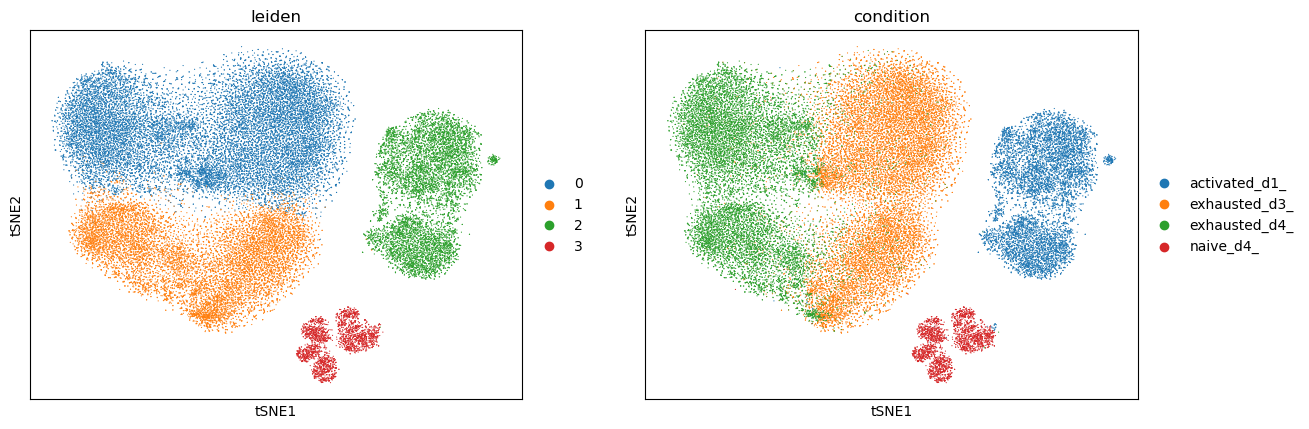

In [10]:

with plt.rc_context(): 
    sc.pl.tsne(grn_adata, color = ['leiden', 'condition'], show=False)
    #plt.savefig(op.join(analysis_output_dir, 'grn_clustering_comparison_tsne.pdf'), bbox_inches="tight")

In [11]:
plt.show()

## Check how well the clustering is concordant with the gene expression clustering

In [12]:
print("\nClustering Score Evaluation")
score, mapping = unify_group_labelling(  adata_raw,grn_adata, 'condition', 'leiden', True)
print(score)
save_clustering_score_to_yaml(analysis_output_dir, score)


Clustering Score Evaluation
0.6693982014135106


In [13]:
# Add the gene expression based clustering back to the GEX expression object.
adata_raw.obs['celltype_remapped'] = grn_adata.obs['leiden_remap'].values


## Make a new anndata object loading more interesting edges per cluster

### Load only viable edges which have reasonable expression of the base edges.

In [14]:
# compute neighborhood expression mask to get the 
add_neighbourhood_expression_mask(adata_raw, grn_adata, strict=False, layer = 'counts' )
grn_adata = add_cluster_based_candidate_edges(grn_adata, threshold=0.5)


In [15]:
# get informative eges and replace the anndata object with the new data.
# Choose inplace =true to update the edges 
index_list = np.where(grn_adata.var['candidate_edge'])[0]
grn_adata = retrieve_edges_by_index(grn_adata, grn_output_dir, index_list, inplace=True)

In [16]:
grn_adata

AnnData object with n_obs × n_vars = 42589 × 32751
    obs: 'Unnamed: 0', 'cell_id', 'condition', 'barcode', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'leiden', 'leiden_remap'
    var: 'source', 'target', 'edge_sums', 'edge_means', 'count_nonzero', 'count_nonzero_norm', 'exhausted_d3__nonzero', 'exhausted_d3__candidate_edge', 'activated_d1__nonzero', 'activated_d1__candidate_edge', 'naive_d4__nonzero', 'naive_d4__candidate_edge', 'candidate_edge'
    uns: 'edge_sum_original_index', 'pca', 'neighbors', 'umap', 'tsne', 'leiden', 'leiden_colors', 'condition_colors'
    obsm: 'X_pca', 'X_umap', 'X_tsne'
    varm: 'PCs'
    layers: 'mask'
  

In [17]:
 #grn_adata2.obs = obs_df
#  grn_adata2.obsm['X_pca'] = grn_adata.obsm['X_pca']
#  grn_adata2.obsm['X_umap'] = grn_adata.obsm['X_umap']


In [18]:
cross_tab = pd.crosstab( grn_adata.obs['condition'],  grn_adata.obs['leiden_remap'])

## Add an external annotation GRN if desired
Make sure that the gene names in the GRN are compatible with the gene names in the data.

In [19]:
 grn_adata = add_external_grn(grn_ad= grn_adata, external_grn=collectri,name_grn='collectri')

In [20]:
# Identify top targets for each source gene within clusters
# - Keeps up to top_per_source strongest targets
# - Removes regulons smaller than min_reg_size

add_neighbourhood_expression_mask(adata_raw,  grn_adata, strict=False, layer = 'counts' )



AnnData object with n_obs × n_vars = 42589 × 32751
    obs: 'Unnamed: 0', 'cell_id', 'condition', 'barcode', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'leiden', 'leiden_remap'
    var: 'source', 'target', 'edge_sums', 'edge_means', 'count_nonzero', 'count_nonzero_norm', 'exhausted_d3__nonzero', 'exhausted_d3__candidate_edge', 'activated_d1__nonzero', 'activated_d1__candidate_edge', 'naive_d4__nonzero', 'naive_d4__candidate_edge', 'candidate_edge', 'edge_in_collectri', 'is_target_collectri', 'is_source_collectri'
    uns: 'edge_sum_original_index', 'pca', 'neighbors', 'umap', 'tsne', 'leiden', 'leiden_colors', 'condition_colors'
    obsm

In [21]:
grn_adata

AnnData object with n_obs × n_vars = 42589 × 32751
    obs: 'Unnamed: 0', 'cell_id', 'condition', 'barcode', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'leiden', 'leiden_remap'
    var: 'source', 'target', 'edge_sums', 'edge_means', 'count_nonzero', 'count_nonzero_norm', 'exhausted_d3__nonzero', 'exhausted_d3__candidate_edge', 'activated_d1__nonzero', 'activated_d1__candidate_edge', 'naive_d4__nonzero', 'naive_d4__candidate_edge', 'candidate_edge', 'edge_in_collectri', 'is_target_collectri', 'is_source_collectri'
    uns: 'edge_sum_original_index', 'pca', 'neighbors', 'umap', 'tsne', 'leiden', 'leiden_colors', 'condition_colors'
    obsm

## Create regulon signatures by selecting the unique top edges per cluster

In [22]:
tp = 20 # Choose 20 targets per cluster
min_reg_size = 3 #Regulon size lower bound
cluster_column = 'condition'
keep_edges = select_top_edges(gene_inter_adata= grn_adata, adata=adata_raw, top_per_source=tp, col_cluster=cluster_column, min_reg_size=min_reg_size, verbose=True)
all_regulons = make_cluster_regulon_dataframe(keep_edges)
# Aggregate the regulons by summing over the edges.
regus = aggregate_edges(keep_edges,  grn_adata, key='unique')
# Make a signature anndata object with the aggregated regulon dataframe
all_signatures = ad.AnnData(X = regus, obs = adata_raw.obs, obsm = adata_raw.obsm)
all_signatures.obs[cluster_column] =  grn_adata.obs[cluster_column].values

# Run differential testing to get the top signatures per group
sc.tl.rank_genes_groups(all_signatures, cluster_column, method='wilcoxon', key_added = "wilcoxon")


Selecting targets for cluster: activated_d1_
Selecting targets for cluster: exhausted_d3_
Selecting targets for cluster: exhausted_d4_
Selecting targets for cluster: naive_d4_
activated_d1_
exhausted_d3_
exhausted_d4_
naive_d4_


In [42]:
all_regulons[all_regulons.cluster == 'exhausted_d4_']

,source,target,sum_of_edge,cluster,set_type
0,Tnfrsf9,Lyst,0.004460,exhausted_d4_,unique
1,Cdk19,Wwox,0.004342,exhausted_d4_,unique
2,Pik3r1,Zswim6,0.001028,exhausted_d4_,unique
3,Ptprj,Ppp3ca,0.005735,exhausted_d4_,unique
4,Adcy7,Lef1,0.001282,exhausted_d4_,unique
...,...,...,...,...,...
4745,Tecpr1,Ets1,0.001416,exhausted_d4_,all
4746,Tecpr1,Arhgap45,0.001359,exhausted_d4_,all
4747,Tecpr1,Ccnd3,0.001234,exhausted_d4_,all
4748,Tecpr1,Slc9a9,0.001206,exhausted_d4_,all


## Save your objects if desired.

In [23]:
#  grn_adata.write_h5ad(op.join(analysis_output_dir, f'{experiment_name}_processed.h5ad'))
# all_signatures.write_h5ad(op.join(analysis_output_dir, f'{experiment_name}_signatures.h5ad'))

## Plot your regulons in a scanpy-like regulon plot

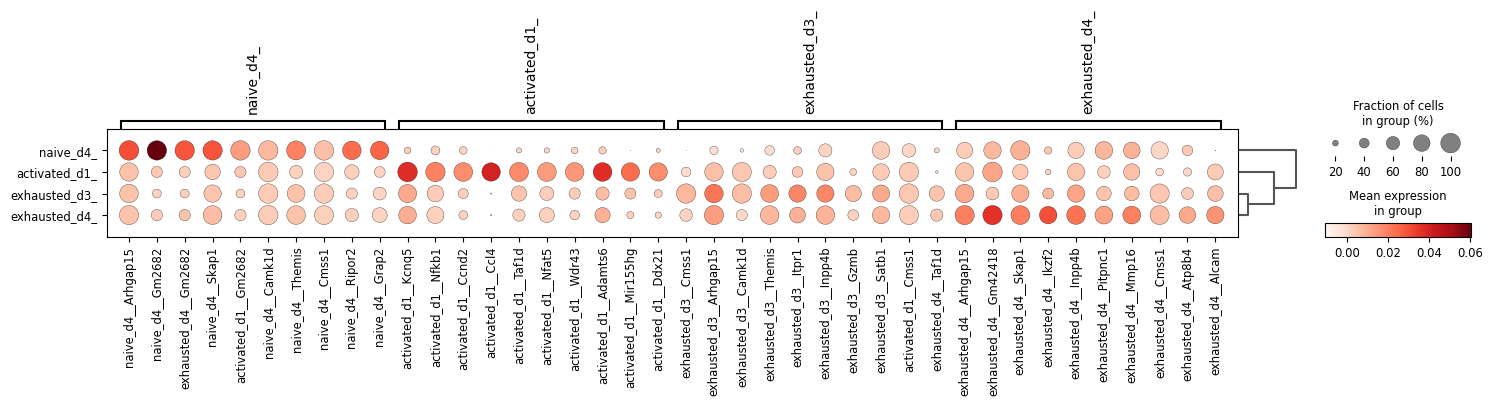

In [51]:
 sc.pl.rank_genes_groups_dotplot(all_signatures, key='wilcoxon')


In [ ]:

def rank_regulon_groups_dotplot(grn_adata_filtered, adata_regl, original_cluster_column = 'leiden', new_cluster_column = 'leiden_remap',  n_genes=10, key="wilcoxon",  cmap='bwr', figsize=(25, 2), values_to_plot="scores", return_fig = True, var_group_rotation=0):
    """_summary_

    Function will throw and error if original cluster column and new cluster are not the same.


    Args:
        grn_adata_filtered (_type_): _description_
        adata_regl (_type_): _description_
        original_cluster_column (str, optional): _description_. Defaults to 'leiden'.
        new_cluster_column (str, optional): _description_. Defaults to 'leiden_remap'.


    Returns:
        _type_: _description_
    """


    cluster_mapping = grn_adata_filtered.obs[[original_cluster_column, new_cluster_column]].drop_duplicates()
    leiden_to_celltype = dict(zip(cluster_mapping[original_cluster_column], cluster_mapping[new_cluster_column]))
    colheaders = grn_adata_filtered.var.columns[grn_adata_filtered.var.columns.str.contains('nonzero')]

    colheaders = list(colheaders)
    if 'count_nonzero' in colheaders:
        colheaders.remove('count_nonzero')
    if 'count_nonzero_norm' in colheaders:
        colheaders.remove('count_nonzero_norm')

    adata_regl.var['source'] = [x.split('_')[-1] for x in adata_regl.var['regulon_name']]

    fractions = {}
    count = 0
    for ri in range(len(adata_regl.var.regulon_name)):
        regulon = adata_regl.var.regulon_name[ri]
        sou = adata_regl.var.source[ri]
        count = count+1
        fractions[f'{regulon}'] =   grn_adata_filtered.var[grn_adata_filtered.var.source == sou][colheaders].sum()
    
    
    fractions = pd.DataFrame(fractions)
    print(fractions)
    fractions.index = [x.replace('_nonzero', '') for x in fractions.index]

    # return fig needs to be true: get plot, modify sizes, then plot or return
    pp = sc.pl.rank_genes_groups_dotplot(adata_regl, n_genes=n_genes, key=key, groupby=new_cluster_column, cmap=cmap, figsize=figsize, values_to_plot=values_to_plot, return_fig=True, var_group_rotation =var_group_rotation)
    print(pp)
    fractions = fractions.reindex(list(pp.dot_size_df.index))

    print(fractions)
    pp.dot_size_df = fractions.loc[:, pp.dot_color_df.columns]
    pp.dot_size_df = pp.dot_size_df/(pp.dot_size_df.max())
    pp.dot_size_df = pp.dot_size_df.fillna(0)
    
    if return_fig:
        return pp
    else:
        pp.show()

{'activated_d1__4933406I18Rik': exhausted_d3__nonzero    93.845007
activated_d1__nonzero    50.284291
naive_d4__nonzero        82.276627
dtype: float64, 'activated_d1__A930015D03Rik': exhausted_d3__nonzero    1.142194
activated_d1__nonzero    4.648865
naive_d4__nonzero        0.965607
dtype: float64, 'activated_d1__AC149090.1': exhausted_d3__nonzero    4.573897
activated_d1__nonzero    6.527919
naive_d4__nonzero        3.353920
dtype: float64, 'activated_d1__Abtb2': exhausted_d3__nonzero     66.901257
activated_d1__nonzero    114.714551
naive_d4__nonzero         65.786243
dtype: float64, 'activated_d1__Adamts6': exhausted_d3__nonzero     99.720731
activated_d1__nonzero    121.621872
naive_d4__nonzero         33.496302
dtype: float64, 'activated_d1__Add3': exhausted_d3__nonzero    42.222539
activated_d1__nonzero    36.661029
naive_d4__nonzero        64.389053
dtype: float64, 'activated_d1__Aff3': exhausted_d3__nonzero    108.889355
activated_d1__nonzero     93.276645
naive_d4__nonzero  

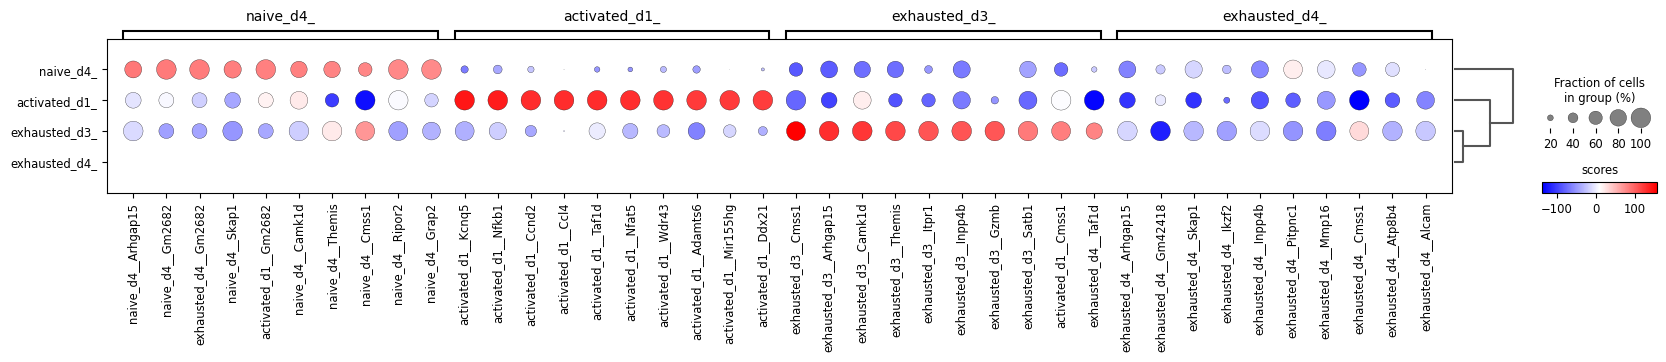

In [60]:
pp = rank_regulon_groups_dotplot( grn_adata, adata_regl=all_signatures, return_fig=True, new_cluster_column=cluster_column,original_cluster_column=cluster_column, n_genes=10, figsize=(20, 2))
pp.show()

## You can plot regulons against each other in a regulon plot to see if they have commonalities.


Get the colors to match between the plots.

In [25]:
# Your existing color mapping logic
color_mapping = dict(zip( grn_adata.obs['condition'].cat.categories,  grn_adata.uns['condition_colors']))

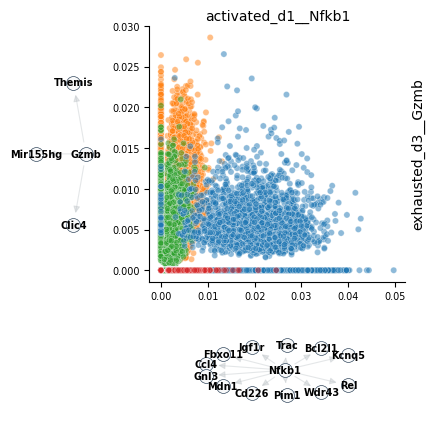

In [26]:
import matplotlib.pyplot as plt
plot_regulon_comparison(all_signatures, all_regulons[all_regulons.set_type == 'unique'], ['activated_d1__Nfkb1' , 'exhausted_d3__Gzmb' ], show_legend=False, palette=color_mapping, cluster_key=cluster_column)
plt.show()

In [27]:
all_signatures.var

,regulon_name,source
activated_d1__4933406I18Rik,activated_d1__4933406I18Rik,4933406I18Rik
activated_d1__A930015D03Rik,activated_d1__A930015D03Rik,A930015D03Rik
activated_d1__AC149090.1,activated_d1__AC149090.1,AC149090.1
activated_d1__Abtb2,activated_d1__Abtb2,Abtb2
activated_d1__Adamts6,activated_d1__Adamts6,Adamts6
...,...,...
naive_d4__Zeb1,naive_d4__Zeb1,Zeb1
naive_d4__Znrf1,naive_d4__Znrf1,Znrf1
naive_d4__Znrf2,naive_d4__Znrf2,Znrf2
naive_d4__Znrf3,naive_d4__Znrf3,Znrf3


In [28]:
grn_adata

AnnData object with n_obs × n_vars = 42589 × 32751
    obs: 'Unnamed: 0', 'cell_id', 'condition', 'barcode', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'leiden', 'leiden_remap'
    var: 'source', 'target', 'edge_sums', 'edge_means', 'count_nonzero', 'count_nonzero_norm', 'exhausted_d3__nonzero', 'exhausted_d3__candidate_edge', 'activated_d1__nonzero', 'activated_d1__candidate_edge', 'naive_d4__nonzero', 'naive_d4__candidate_edge', 'candidate_edge', 'edge_in_collectri', 'is_target_collectri', 'is_source_collectri', 'edge_support_c'
    uns: 'edge_sum_original_index', 'pca', 'neighbors', 'umap', 'tsne', 'leiden', 'leiden_colors', 'conditio

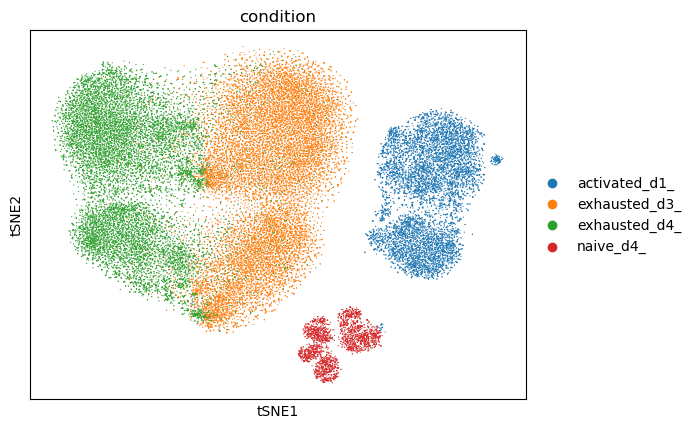

In [29]:
sc.pl.tsne( grn_adata, color = 'condition')

In [30]:
## Plot the signatures onto the gene expression plot

### First 

In [31]:
all_signatures.obsm['X_tsne'] = grn_adata.obsm['X_tsne']
adata_raw.obsm['X_tsne'] = grn_adata.obsm['X_tsne']

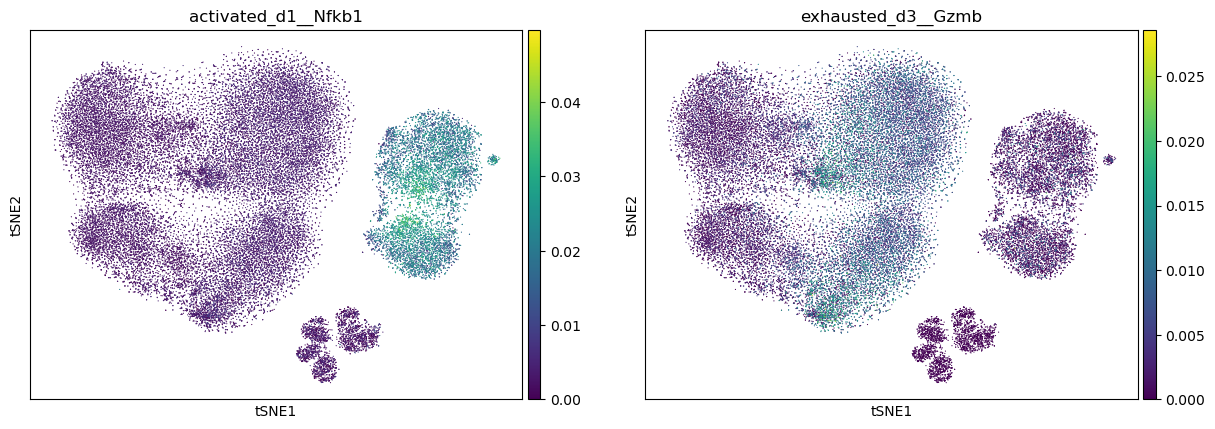

In [32]:
sc.pl.tsne(all_signatures, color = ['activated_d1__Nfkb1',  'exhausted_d3__Gzmb'])

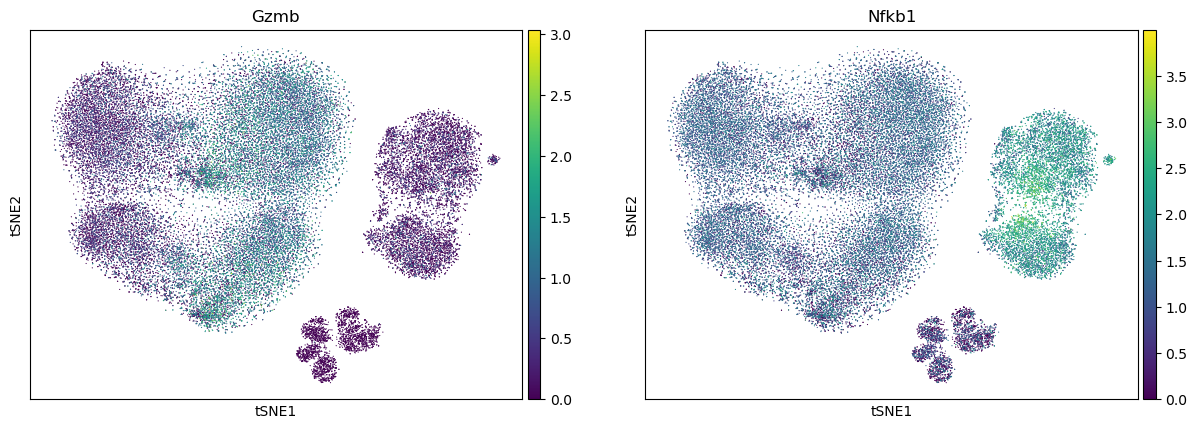

In [33]:
sc.pl.tsne(adata_raw, color = ['Gzmb', 'Nfkb1'])

In [34]:
all_regulons[(all_regulons.set_type=='unique') & (all_regulons.cluster =='B cell')]

,source,target,sum_of_edge,cluster,set_type


In [35]:
all_signatures.obs

,cell_id,condition,barcode,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,...,log1p_total_counts_mt,pct_counts_mt,total_counts_ribo,log1p_total_counts_ribo,pct_counts_ribo,total_counts_hb,log1p_total_counts_hb,pct_counts_hb,leiden,celltype_remapped
1,AAACAGCCAAGTCGCT-1,exhausted_d3_,exhausted_d3_AAACAGCCAAGTCGCT-1,1057,6.964136,1154.760010,7.052514,10.238612,17.249309,29.544821,...,0.0,0.0,52.331223,3.976522,4.531783,0.000000,0.000000,0.000000,0,exhausted_d3_
3,AAACAGCCAATCCTGA-1,exhausted_d3_,exhausted_d3_AAACAGCCAATCCTGA-1,786,6.668228,1068.080078,6.974554,10.859371,19.269902,31.038087,...,0.0,0.0,41.422657,3.747683,3.878235,1.256940,0.814010,0.117682,0,exhausted_d3_
4,AAACAGCCACAAAGCG-1,exhausted_d3_,exhausted_d3_AAACAGCCACAAAGCG-1,1791,7.491088,1372.912109,7.225418,8.236925,13.207325,21.773320,...,0.0,0.0,45.502716,3.839511,3.314321,0.609354,0.475833,0.044384,0,exhausted_d3_
5,AAACAGCCACACTAAT-1,exhausted_d3_,exhausted_d3_AAACAGCCACACTAAT-1,2537,7.839132,1405.645630,7.248963,8.150983,12.765966,20.532528,...,0.0,0.0,46.741779,3.865807,3.325289,0.656573,0.504751,0.046710,0,exhausted_d3_
6,AAACAGCCACGTAATT-1,exhausted_d3_,exhausted_d3_AAACAGCCACGTAATT-1,670,6.508769,945.713562,6.852997,12.999680,22.617504,36.572103,...,0.0,0.0,56.286514,4.048065,5.951751,1.276272,0.822539,0.134953,0,exhausted_d3_
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10153,TTTGTGGCACATACTG-1,naive_d4_,naive_d4_TTTGTGGCACATACTG-1,1156,7.053586,1242.761963,7.125896,9.766762,16.627760,27.966568,...,0.0,0.0,10.582696,2.449512,0.851547,0.881891,0.632277,0.070962,3,naive_d4_
10164,TTTGTGTTCTAATCCT-1,naive_d4_,naive_d4_TTTGTGTTCTAATCCT-1,728,6.591674,968.776672,6.877066,13.428907,22.287916,36.480280,...,0.0,0.0,13.343728,2.663313,1.377379,0.000000,0.000000,0.000000,3,naive_d4_
10166,TTTGTTGGTAGTTAAC-1,naive_d4_,naive_d4_TTTGTTGGTAGTTAAC-1,793,6.677083,1072.695190,6.978861,12.166924,20.737604,36.291567,...,0.0,0.0,9.704820,2.370694,0.904714,0.000000,0.000000,0.000000,3,naive_d4_
10167,TTTGTTGGTCATCAAG-1,naive_d4_,naive_d4_TTTGTTGGTCATCAAG-1,915,6.820016,1114.516968,7.017073,11.087758,18.798173,32.548444,...,0.0,0.0,19.491638,3.020017,1.748887,1.552527,0.937084,0.139300,3,naive_d4_


In [36]:
bcrank = sc.get.rank_genes_groups_df(all_signatures, group = 'exhausted_d3_', key  = 'wilcoxon')

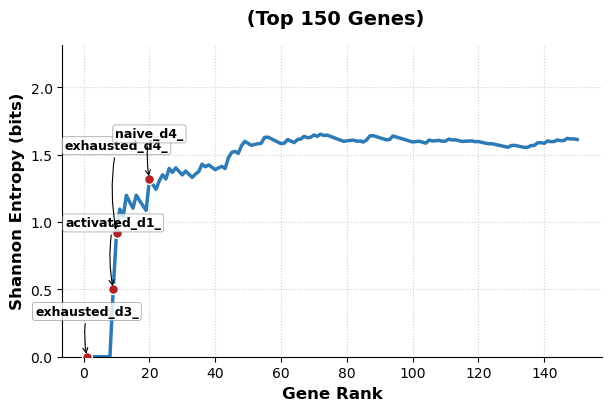

In [37]:
bcrank_entropy(bcrank, top_n=150, title="", figsize=(6,4))

In [38]:
filtered_df = all_regulons[(all_regulons.set_type == 'unique') & (all_regulons.cluster == 'exhausted_d3_')].nlargest(400,'sum_of_edge')
my_edges = [f'{e1}_{e2}' for (e1,e2) in zip(filtered_df.source.values, filtered_df.target.values)]
signi = aggregate_edges_arbitrary( grn_adata, {'exhausted_d3_': my_edges})
grn_adata.obs['exhausted_d3_'] = signi['exhausted_d3_'].values

In [39]:
sc.pl.tsne( grn_adata, color = 'B cell GRN' )

KeyError: 'Could not find key B cell GRN in .var_names or .obs.columns.'

In [ ]:

import igraph as ig

def make_single_celltype_graph(filtered_df, tfs = None):
    g = ig.Graph.TupleList(filtered_df[['source', 'target', 'sum_of_edge']].itertuples(index=False), directed=False, weights=True)

    # 7. LAYOUT & PLOTTING
    layout = g.layout_kamada_kawai()

    if tfs is not None:
        g.vs["is_tf"] = [name in tfs for name in g.vs["name"]]
        colors = ["#ff7f0e" if is_tf else "#1f77b4" for is_tf in g.vs["is_tf"]]
    else:
        colors = ["#ff7f0e" for node in g.vs["is_tf"]]

    fig, ax = plt.subplots(figsize=(22, 22))

    ig.plot(g, 
    layout=layout,
    target=ax,
    vertex_label_size=11,
        vertex_label_dist=2.0,
        edge_alpha=0.15,
        edge_arrow_size=0.3,
        vertex_color=colors,
        vertex_label=g.vs["name"],
        edge_color = 'lightblue'
        )
    plt.show()

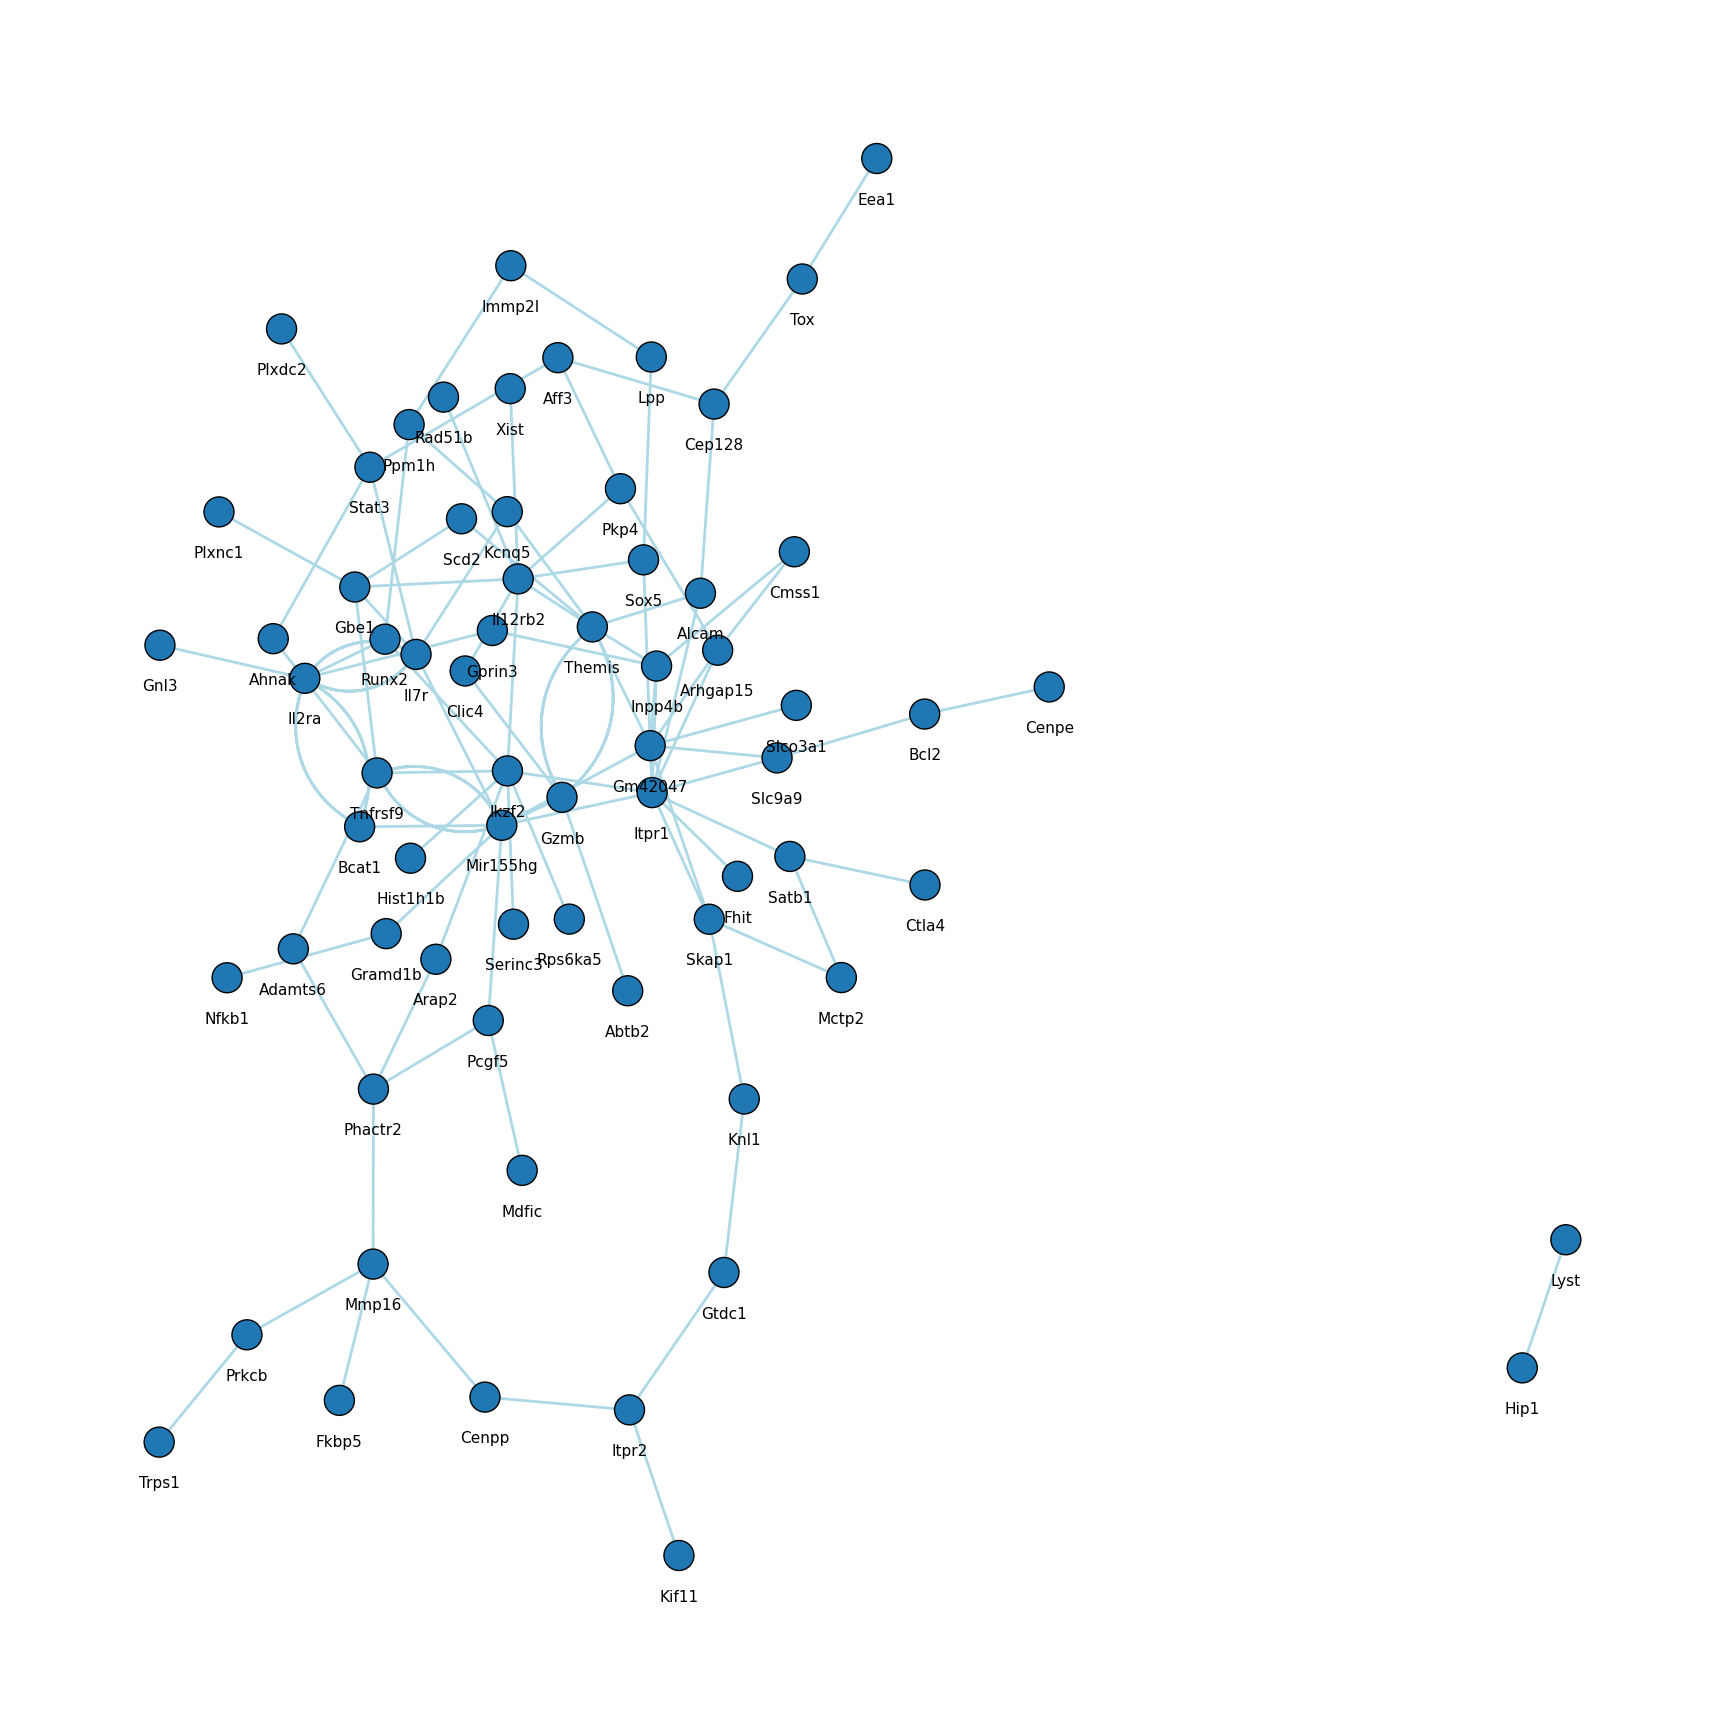

In [ ]:
filtered_df = all_regulons[(all_regulons.set_type == 'unique') & (all_regulons.cluster == 'exhausted_d3_')].nlargest(100,'sum_of_edge')
make_single_celltype_graph(filtered_df, tfs = set(collectri.source.unique()))

In [ ]:
filtered_df

,source,target,sum_of_edge,cluster,set_type
215,Arhgap15,Itpr1,0.024663,exhausted_d3_,unique
475,Inpp4b,Gm42047,0.020955,exhausted_d3_,unique
257,Aff3,Cep128,0.019758,exhausted_d3_,unique
361,Arhgap15,Gm42047,0.019533,exhausted_d3_,unique
46,Aff3,Pkp4,0.019308,exhausted_d3_,unique
...,...,...,...,...,...
387,Runx2,Il2ra,0.007074,exhausted_d3_,unique
44,Gzmb,Themis,0.007033,exhausted_d3_,unique
457,Phactr2,Arap2,0.006980,exhausted_d3_,unique
75,Tnfrsf9,Mir155hg,0.006971,exhausted_d3_,unique


In [ ]:
import igraph as ig
import matplotlib.pyplot as plt


def extract_tf_subgraph(filtered_df, tfs):
    
    g = ig.Graph.TupleList(filtered_df[['source', 'target', 'sum_of_edge']].itertuples(index=False), directed=False, weights=True)

    # 7. LAYOUT & PLOTTING
    #layout = g.layout_kamada_kawai()

    if tfs is not None:
        g.vs["is_tf"] = [name in tfs for name in g.vs["name"]]
        colors = ["#ff7f0e" if is_tf else "#1f77b4" for is_tf in g.vs["is_tf"]]
    else:
        colors = ["#ff7f0e" for node in g.vs["is_tf"]]


    tf_indices = [v.index for v in g.vs if v["is_tf"]]
    tf_subgraph = g.subgraph(tf_indices)

    # 2. Get the largest connected component
    components = tf_subgraph.connected_components(mode='weak')
    giant_component = components.giant()

    # --- FIX: Ensure the weight attribute exists ---
    # If 'sum_of_edge' is missing, it might be stored simply as 'weight' 
    # because of how TupleList was initialized.
    attr_name = 'sum_of_edge' if 'sum_of_edge' in giant_component.es.attributes() else 'weight'

    try:
        edge_weights = giant_component.es[attr_name]
    except KeyError:
        # Fallback if no weights exist at all
        edge_weights = [1] * len(giant_component.es)

    # 3. Plotting
    layout = giant_component.layout_kamada_kawai()
    fig, ax = plt.subplots(figsize=(8, 8))

    ig.plot(
        giant_component,
        target=ax,
        layout=layout,
        vertex_size=25,
        vertex_color="#ff7f0e", 
        vertex_label=giant_component.vs["name"],
        vertex_label_size=12,
        vertex_label_dist=2.0,
        edge_alpha=1,

        edge_arrow_size=0.5
    )

    plt.title("Largest Connected TF Regulatory Module", fontsize=20)
    plt.show()

In [ ]:
import igraph as ig
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.lines import Line2D


def create_inferface_graph(filtered_df, target_clusters, combo_colors, top_edges = 200):

    filtered_df = all_regulons[
        (all_regulons.set_type == 'unique') & 
        (all_regulons.cluster.isin(target_clusters))
    ].groupby('cluster', group_keys=False).apply(lambda x: x.nlargest(top_edges, 'sum_of_edge'))


    target_combos = filtered_df.groupby('target')['cluster'].apply(
        lambda x: " & ".join(sorted(list(set(x))))
    ).to_dict()

    # source_combos = filtered_df.groupby('source')['cluster'].apply(
    #     lambda x: " & ".join(sorted(list(set(x))))
    # ).to_dict()


    def get_color(name):
        combo_string = target_combos.get(name, "")
        # if combo_string == "":
        #     combo_string = source_combos.get(name, "")
        if combo_string in combo_colors:
            return combo_colors[combo_string]
        elif " & " in combo_string:
            return "#7f7f7f" # Grey for any intersection not explicitly defined above
        else:
            return "#e0e0e0" # Light Grey for TFs/Sources


    g = ig.Graph.TupleList(
        filtered_df[['source', 'target', 'sum_of_edge']].itertuples(index=False), 
        directed=True, weights=True
    )
    g.vs["color"] = [get_color(name) for name in g.vs["name"]]

    components = g.connected_components(mode='weak')
    giant_component = components.giant()

    
    layout = giant_component.layout_kamada_kawai()
    fig, ax = plt.subplots(figsize=(16, 14))
    plt.subplots_adjust(right=0.75)

    ig.plot(
        giant_component, layout=layout, target=ax,
        vertex_size=12,
        vertex_color=g.vs["color"],
        vertex_label=g.vs["name"],
        vertex_label_size=8,
        edge_alpha=0.1,
        edge_arrow_size = 0.5,
        edge_arrow_width = 0.5,

        edge_color='#cccccc',
        
    )

    legend_elements = [
        Line2D([0], [0], marker='o', color='w', label=k, markerfacecolor=v, markersize=8) 
        for k, v in combo_colors.items()
    ]
    legend_elements.append(Line2D([0], [0], marker='o', color='w', label='Other Intersection', 
                                markerfacecolor='#7f7f7f', markersize=8))

    ax.legend(handles=legend_elements, loc='center left', bbox_to_anchor=(1, 0.5), title="Cell Type Groups")
    plt.show()


In [ ]:
grn_adata.obs

,Unnamed: 0,cell_id,condition,barcode,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,...,total_counts_ribo,log1p_total_counts_ribo,pct_counts_ribo,total_counts_hb,log1p_total_counts_hb,pct_counts_hb,leiden,leiden_remap,B cell GRN,exhausted_d3_
0,1,AAACAGCCAAGTCGCT-1,exhausted_d3_,exhausted_d3_AAACAGCCAAGTCGCT-1,1057,6.964136,1154.76000,7.052514,10.238612,17.249309,...,52.331223,3.976522,4.531783,0.000000,0.000000,0.000000,0,exhausted_d3_,0.005585,0.005585
1,3,AAACAGCCAATCCTGA-1,exhausted_d3_,exhausted_d3_AAACAGCCAATCCTGA-1,786,6.668228,1068.08010,6.974554,10.859371,19.269902,...,41.422657,3.747683,3.878235,1.256941,0.814010,0.117682,0,exhausted_d3_,0.002808,0.002808
2,4,AAACAGCCACAAAGCG-1,exhausted_d3_,exhausted_d3_AAACAGCCACAAAGCG-1,1791,7.491088,1372.91210,7.225418,8.236925,13.207325,...,45.502716,3.839511,3.314321,0.609354,0.475833,0.044384,0,exhausted_d3_,0.006722,0.006722
3,5,AAACAGCCACACTAAT-1,exhausted_d3_,exhausted_d3_AAACAGCCACACTAAT-1,2537,7.839132,1405.64560,7.248963,8.150983,12.765966,...,46.741780,3.865807,3.325289,0.656573,0.504751,0.046710,1,exhausted_d3_,0.007188,0.007188
4,6,AAACAGCCACGTAATT-1,exhausted_d3_,exhausted_d3_AAACAGCCACGTAATT-1,670,6.508769,945.71356,6.852997,12.999680,22.617504,...,56.286514,4.048065,5.951751,1.276272,0.822539,0.134953,1,exhausted_d3_,0.004458,0.004458
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42584,10153,TTTGTGGCACATACTG-1,naive_d4_,naive_d4_TTTGTGGCACATACTG-1,1156,7.053586,1242.76200,7.125896,9.766762,16.627760,...,10.582696,2.449512,0.851546,0.881891,0.632277,0.070962,3,naive_d4_,0.001684,0.001684
42585,10164,TTTGTGTTCTAATCCT-1,naive_d4_,naive_d4_TTTGTGTTCTAATCCT-1,728,6.591674,968.77670,6.877066,13.428907,22.287916,...,13.343728,2.663313,1.377379,0.000000,0.000000,0.000000,3,naive_d4_,0.001062,0.001062
42586,10166,TTTGTTGGTAGTTAAC-1,naive_d4_,naive_d4_TTTGTTGGTAGTTAAC-1,793,6.677083,1072.69520,6.978861,12.166924,20.737604,...,9.704820,2.370694,0.904714,0.000000,0.000000,0.000000,3,naive_d4_,0.002327,0.002327
42587,10167,TTTGTTGGTCATCAAG-1,naive_d4_,naive_d4_TTTGTTGGTCATCAAG-1,915,6.820016,1114.51700,7.017073,11.087758,18.798173,...,19.491638,3.020017,1.748887,1.552527,0.937084,0.139300,3,naive_d4_,0.001126,0.001126


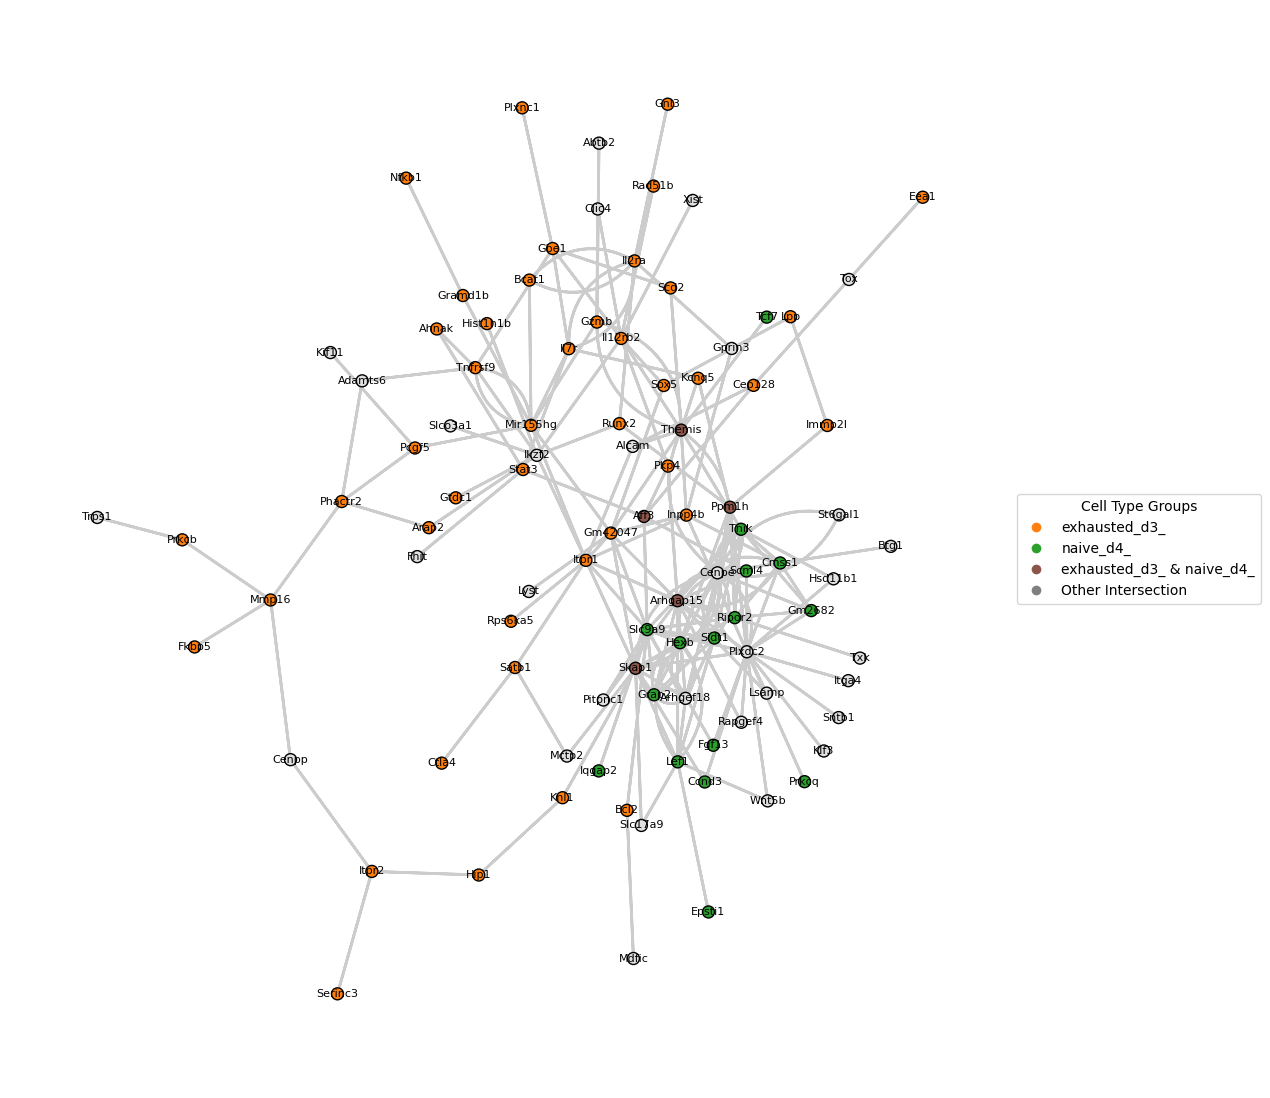

In [ ]:

target_clusters = [ 'exhausted_d3_', 'naive_d4_']

combo_colors = {
    # Individual "Core 3" (Originals)
    target_clusters[0]: '#ff7f0e',            # Orange
    target_clusters[1]: '#2ca02c',            # Green
    f'{target_clusters[0]} & {target_clusters[1]}': '#8c564b', # Brown
}
create_inferface_graph(filtered_df, target_clusters, combo_colors, top_edges=100)